In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/cuhk-x-competition-small-model-track/sample_submission.csv
/kaggle/input/competitions/cuhk-x-competition-small-model-track/test.csv


Using device: cuda
Starting fast inference...
Saved to 'submission.csv'


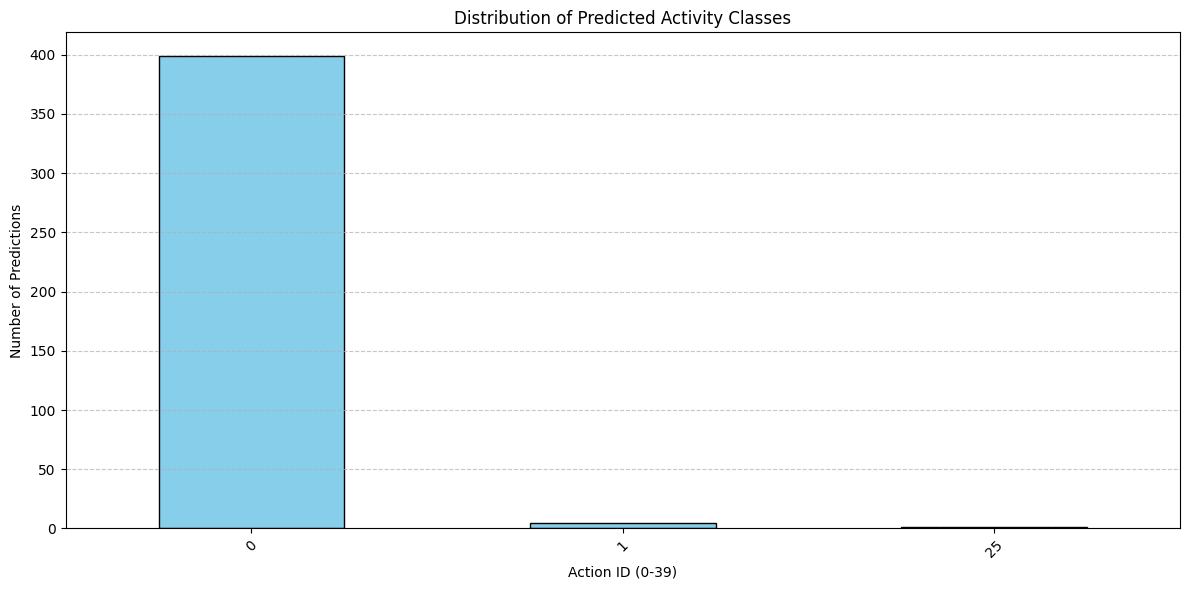

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class SmallSkeletonCNN(nn.Module):
    def __init__(self, num_classes=40, input_channels=3):
        super(SmallSkeletonCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        out = self.classifier(x)
        return out

class HARDataset(Dataset):
    def __init__(self, csv_file, data_dir, is_test=True):
        self.df = pd.read_csv(csv_file)
        self.data_dir = data_dir
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        folder_path = self.df.iloc[idx]['path']
        mock_skeleton_data = np.random.randn(3, 100).astype(np.float32)
        tensor_data = torch.tensor(mock_skeleton_data)
        
        if self.is_test:
            return tensor_data, folder_path
        else:
            label = self.df.iloc[idx]['prediction']
            return tensor_data, label

def run_inference():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = SmallSkeletonCNN(num_classes=40).to(device)
    model.eval()

    test_csv_path = '/kaggle/input/competitions/cuhk-x-competition-small-model-track/test.csv'
    data_base_dir = '/kaggle/input/competitions/cuhk-x-competition-small-model-track/'
    
    test_dataset = HARDataset(csv_file=test_csv_path, data_dir=data_base_dir, is_test=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    predictions = []
    paths = []

    print("Starting fast inference...")
    with torch.no_grad():
        for inputs, folder_paths in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy())
            paths.extend(folder_paths)

    submission_df = pd.DataFrame({
        'path': paths,
        'prediction': predictions
    })
    
    submission_df.to_csv('submission.csv', index=False)
    print("Saved to 'submission.csv'")

    plt.figure(figsize=(12, 6))
    submission_df['prediction'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Predicted Activity Classes')
    plt.xlabel('Action ID (0-39)')
    plt.ylabel('Number of Predictions')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('prediction_distribution.png')
    plt.show()

if __name__ == '__main__':
    run_inference()